<a href="https://colab.research.google.com/github/jjmoncus/MV_coursework_2/blob/main/Machine_Vision_Final_Lab_Model_Inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
# ===== INSTALL DEPENDENCIES =====
!pip install huggingface_hub
!pip install boto3 -q
!pip install opencv-python torch numpy torchvision tqdm

python(14489) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


python(14491) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(14493) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [13]:
# Import the required libraries
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from huggingface_hub import hf_hub_download
import boto3
from botocore import UNSIGNED
from botocore.config import Config
import os
import cv2
import numpy as np
from tqdm import tqdm
import time

# Please double, triple, quadruple check that the below code runs without errors before submitting.

## TODO 1 - Enter your HuggingFace username below:

In [14]:
hf_username = "jjmoncus1"

## TODO 2 - Define your model EXACTLY as you did in your training code (otherwise there will be errors, and, possibly, tears).

Note below the classname is 'YourModelArchitecture'. That's because it literally needs to be YOUR MODEL ARCHITECTURE. This class definition is later referred to below in the 'load_model_from_hub' method. The architecture must match here, or it will not be able to instantiate the model weights correctly once it downloads them from HuggingFace. Pay very close attention to getting this right, please.

Replace the below code, and replace the corresponding line in the 'load_model_from_hub' method.

In [15]:
import torch
import torch.nn as nn
from torchvision import models

class VideoResNetModel(nn.Module):
    def __init__(self, use_pretrained=True, num_classes = 10):
        super().__init__()
        
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if use_pretrained else None)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        for param in self.backbone.parameters():
            param.requires_grad = False  # Gradients are no longer calculated/stored

        # Temporal Processor
        # ResNet18 (after Global Average Pool) outputs 512 features per frame.
        # added one more convolutional layer than before
        self.temporal_conv = nn.Sequential(
            nn.Conv1d(512, 256, kernel_size=3, stride=2, padding=1), # 100 -> 50
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.1), # LeakyReLU helps with vanishing gradients
            nn.Dropout1d(p = .2),
            nn.Conv1d(256, 128, kernel_size=3, stride=2, padding=1), # 50 -> 25
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1), # LeakyReLU helps with vanishing gradients
            nn.Dropout1d(p = .2),
            nn.Conv1d(128, 64, kernel_size=3, stride=2, padding=1), # 25 -> 13
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
            nn.Dropout1d(p = .2),
            nn.Conv1d(64, 32, kernel_size=3, stride=2, padding=1),  # 13 -> 7
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.1),
            nn.AdaptiveAvgPool1d(1) # sqashes to 1 "frame"
        )
        
        # 5. Classifier
        # Output of temporal is [B, 32, 13]. Flattened = 32 * 1 = 32
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32, 112),
            nn.LeakyReLU(0.1),
            nn.Dropout(p = .2),
            nn.Linear(112, num_classes),
        )

    def forward(self, x):
        # x: [B, C, T, H, W]
        B, C, T, H, W = x.shape
        
        # Reshape for Spatial: [B*T, C, H, W]
        x_in = x.transpose(1, 2).reshape(B * T, C, H, W) 
        
        # Pass through ResNet backbone
        # Output is [B*T, 512, 1, 1]
        spatial_features = self.backbone(x_in) 
        
        # Reshape for Temporal: [B, 512, T]
        temporal_in = spatial_features.view(B, T, -1).transpose(1, 2)
        
        # Temporal Conv
        temporal_out = self.temporal_conv(temporal_in)
        
        # Classify
        return self.classifier(temporal_out)

## Download the test data from s3, and create the corresponding dataset + dataloader.

There's no TODO for you here. This text is just here to explain to you what this code does.

In this instance, the test data IS the training data you were provided in the Model Training notebook. This is by design. You do not have access to the test data. This is a simple check to make sure the mechanics of this notebook work.

You should achieve the same accuracy here in this notebook, as you did in your previous notebook (random seed notwithstanding).

In [16]:
# =============================================================================
# DOWNLOAD TEST DATA FROM S3
# =============================================================================

def download_test_data(bucket_name='training-and-validation-data',download_dir='./test-data'):
    s3 = boto3.client('s3', config=Config(signature_version=UNSIGNED))

    bucket_name = 'prism-mvta'
    prefix = 'training-and-validation-data/'

    os.makedirs(download_dir, exist_ok=True)

    paginator = s3.get_paginator('list_objects_v2')
    pages = paginator.paginate(Bucket=bucket_name, Prefix=prefix)

    video_names = []

    for page in pages:
        if 'Contents' not in page:
            print("No files found at the specified path!")
            break

        print("Downloading test data:\n")
        for obj in tqdm(page['Contents']):
            key = obj['Key']
            filename = os.path.basename(key)

            if not filename:
                continue

            video_names.append(filename)
            local_path = os.path.join(download_dir, filename)
            # print(f"Downloading: {filename}")
            s3.download_file(bucket_name, key, local_path)

    print(f"\nDownloaded {len(video_names)} test videos")
    return download_dir


# ============================================================================= # DATASET AND DATALOADER =============================================================================

class VideoDataset(Dataset):
    def __init__(self, video_dir, frame_size=(224, 224)):
        self.video_dir = video_dir
        self.frame_size = frame_size

        self.video_files = [
            f for f in os.listdir(video_dir)
            if f.endswith(('.mp4', '.avi', '.mov'))
        ]

        self.labels = [
            int(f.split('_')[0]) for f in self.video_files
        ]

    def __len__(self):
        return len(self.video_files)

    def __getitem__(self, idx):
        video_path = os.path.join(self.video_dir, self.video_files[idx])
        frames = self._load_video(video_path)
        label = self.labels[idx]
        return frames, label

    def _load_video(self, path):
        cap = cv2.VideoCapture(path)

        frames = []
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (self.frame_size[1], self.frame_size[0]))
            frames.append(frame)

        cap.release()

        frames = torch.from_numpy(np.array(frames)).permute(3, 0, 1, 2).float() / 255.0
        return frames


def collate_fn(batch):
    """Pad all videos to 1000 frames."""
    frames_list, labels = zip(*batch)

    # REMEMBER TO CHANGE THIS BACK TO 1000
    target_frames = 100

    padded_frames = []
    for frames in frames_list:
        num_frames = frames.shape[1]
        if num_frames < target_frames:
            padding = torch.zeros(frames.shape[0], target_frames - num_frames, frames.shape[2], frames.shape[3])
            frames = torch.cat([frames, padding], dim=1)
        elif num_frames > target_frames:
            frames = frames[:, :target_frames, :, :]
        padded_frames.append(frames)

    frames_batch = torch.stack(padded_frames, dim=0)
    labels_batch = torch.tensor(labels)

    return frames_batch, labels_batch


## TODO 3 - Download your model from HuggingFace and instantiate it

Replace line 8 of the below code. Line 8 is where you instantiate YOUR MODEL ARCHITECTURE (which you re-defined above) with the weights you download from HuggingFace. Make sure you get the class name, and the arguments to the __init__ method correct.


This code just downloads the same model which you uploaded in the last notebook.

In [17]:
# =============================================================================
# DOWNLOAD MODEL FROM HUGGING FACE
# =============================================================================

def load_model_from_hub(repo_id):
    model_path = hf_hub_download(repo_id=repo_id, filename="model.pt")

    model = VideoResNetModel()
    model.load_state_dict(torch.load(model_path, map_location='cpu'))

    print(f"Model loaded from {repo_id}")
    return model

model = load_model_from_hub(f"{hf_username}/mv-final-assignment")

Model loaded from jjmoncus1/mv-final-assignment


In [18]:
model

VideoResNetModel(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_s

## TODO 4

Make sure the below code correctly evaluates your model performance on the given data!

This is your last chance to verify this before submission.

In [19]:
# def evaluate(model, test_loader, dataset, device):
#     model.eval()
#     correct = 0
#     total = 0

#     all_preds = []
#     all_labels = []
#     all_times = []

#     print("\n")

#     with torch.no_grad():
#         for idx, (frames, labels) in enumerate(test_loader):
#             frames, labels = frames.to(device), labels.to(device)

#             # Time the forward pass
#             start_time = time.time()
#             outputs = model(frames)
#             # outputs = torch.flatten(outputs)
#             if device.type == 'cuda':
#                 torch.cuda.synchronize()  # wait for GPU to finish
#             end_time = time.time()

#             inference_time = (end_time - start_time) * 1000  # ms
#             all_times.append(inference_time)

#             _, preds = torch.max(outputs, 1)
#             preds = preds + 1

#             for i in range(labels.size(0)):
#                 batch_idx = idx * test_loader.batch_size + i
#                 video_name = dataset.video_files[batch_idx]
#                 pred = preds[i].item()
#                 true_label = labels[i].item()
#                 is_correct = "✓" if pred == true_label else "✗"

#                 print(f"{is_correct}  pred={pred}  true={true_label}  |  {inference_time:>7.1f}ms  |  {video_name}")

#             correct += preds.eq(labels).sum().item()
#             total += labels.size(0)

#             all_preds.extend(preds.cpu().numpy())
#             all_labels.extend(labels.cpu().numpy())

#     accuracy = correct / total
#     return accuracy, all_preds, all_labels, all_times


# # =============================================================================
# # RUN INFERENCE
# # =============================================================================

# def run_inference(model, bucket_name='training-and-validation-data'):
#     device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#     print(f"Using device: {device}")

#     # Download test data
#     # NEED TO UNCOMMENT THIS BEFORE SUBMITTING
#     # test_dir = download_test_data(bucket_name, './test-data')

#     model = model.to(device)

#     # Create dataloader
#     # NEED TO CHANGE THIS BACK TO `test_dir`
#     test_dataset = VideoDataset('./test-data', frame_size=(224, 224))
#     test_loader = DataLoader(
#         test_dataset,
#         batch_size=1,
#         shuffle=False,
#         num_workers=0,
#         collate_fn=collate_fn
#     )

#     print(f"\nRunning inference on {len(test_dataset)} test videos...")

#     # Warmup (optional, helps get consistent GPU timings)
#     if device.type == 'cuda':
#         dummy = torch.randn(1, 3, 1000, 224, 224).to(device)
#         with torch.no_grad():
#             _ = model(dummy)
#         torch.cuda.synchronize()

#     total_start = time.time()
#     accuracy, preds, labels, times = evaluate(model, test_loader, test_dataset, device)
#     total_end = time.time()

#     # Summary
#     num_correct = sum(p == l for p, l in zip(preds, labels))
#     num_wrong = len(preds) - num_correct

#     print("\n" + "="*50)
#     print("SUMMARY")
#     print("="*50)
#     print(f"Total videos:         {len(preds)}")
#     print(f"Correct:              {num_correct}")
#     print(f"Incorrect:                {num_wrong}")
#     print(f"")
#     print(f"ACCURACY:             {accuracy*100:.2f}%")
#     print(f"")
#     print(f"Total time:           {total_end - total_start:.2f}s")
#     print(f"Avg per video:        {sum(times) / len(times):.1f}ms")
#     print(f"Min latency:          {min(times):.1f}ms")
#     print(f"Max latency:          {max(times):.1f}ms")
#     print("="*50)
#     return accuracy, preds, labels

# _, _, _ = run_inference(model)

Using device: mps

Running inference on 77 test videos...


✗  pred=1  true=2  |  2_sadfasjldkfjaseifj.mp4
✗  pred=1  true=2  |  2_sdafkjaslkclaksdjkas.mp4
✗  pred=1  true=4  |  4_kling_20251206_Text_to_Video_Generate_a_28_0.mp4
✗  pred=1  true=3  |  3_kling_dskfseu.mp4
✗  pred=9  true=4  |  4_kling_20251209_Text_to_Video_Generate_a_190_0.mp4
✗  pred=6  true=3  |  3_kling_kdjflaskdjf.mp4
✗  pred=6  true=2  |  2_dsalkfjalwkenlke.mp4
✓  pred=3  true=3  |  3_dsjlaeijlksjdfie.mp4
✓  pred=3  true=3  |  3_kling_20251205_Text_to_Video_On_a_playg_5028_0.mp4
✗  pred=6  true=4  |  4_sadlfkjlknewkjejk.mp4
✗  pred=9  true=3  |  3_kling_20251206_Text_to_Video_Generate_a_315_2.mp4
✗  pred=7  true=4  |  4_kling_20251209_Text_to_Video_Generate_a_561_1.mp4
✗  pred=6  true=2  |  2_difficult_2.mp4
✗  pred=9  true=3  |  3_sdlkjslndflkseijlkjef.mp4
✗  pred=1  true=3  |  3_kling_20251206_Text_to_Video_Generate_a_315_0.mp4
✓  pred=6  true=6  |  6_dfjewaijsldkjfsaef.mp4
✗  pred=9  true=4  |  4_kling_20251209_

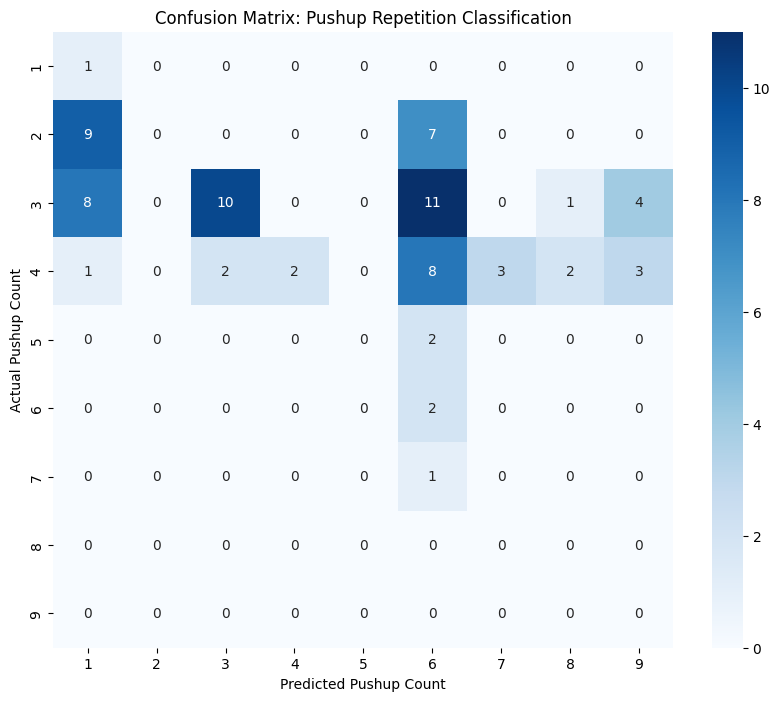


SUMMARY
Total videos:         77
Correct:              15
Incorrect:                62

ACCURACY:             19.48%

Total time:           64.22s
Avg per video:        152.0ms
Min latency:          143.1ms
Max latency:          311.1ms


In [20]:
# from tqdm import tqdm
import time
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# More comprehensive model evaluation (no transformations)
def full_evaluate(model, test_loader, dataset, device):
    model.eval()
    correct = 0
    total = 0

    all_preds = []
    all_labels = []
    all_times = []

    print("\n")

    with torch.no_grad():
        # for each batch, ...
        for idx, (frames, labels) in enumerate(test_loader):
            
            # ... grab the frames and labels,
            frames, labels = frames.to(device), labels.to(device)

            # ... time the forward pass,
            start_time = time.time()
            outputs = model(frames)
            if device.type == 'cuda':
                torch.cuda.synchronize()  # wait for GPU to finish
            elif device.type == "mps":
                torch.mps.synchronize()  # wait for GPU to finish
            end_time = time.time()
            inference_time = (end_time - start_time) * 1000  # ms
            all_times.append(inference_time)

            # ... make predictions
            _, preds = torch.max(outputs, 1)
            preds = preds + 1

            # ... evalute if we're correct or not
            for i in range(labels.size(0)):
                batch_idx = idx * test_loader.batch_size + i
                video_name = dataset.video_files[batch_idx]
                pred = preds[i].item()
                true_label = labels[i].item()
                is_correct = "✓" if pred == true_label else "✗"
                print(f"{is_correct}  pred={pred}  true={true_label}  |  {video_name}")

            # ... tally our results
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Now, generate a confusion matrix of all our incorrect predictions, ...
    unique_labels = sorted(list(set(all_labels) | set(all_preds)))
    cm = confusion_matrix(all_labels, all_preds, labels=unique_labels)
    plot_confusion_matrix(cm, unique_labels)

    # ... and tally our final accuracy
    accuracy = correct / total
    return accuracy, all_preds, all_labels, all_times

def plot_confusion_matrix(cm, labels):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted Pushup Count')
    plt.ylabel('Actual Pushup Count')
    plt.title('Confusion Matrix: Pushup Repetition Classification')
    plt.show()
    
def run_inference(model, bucket_name='training-and-validation-data'):

    # Find and apply device
    if torch.cuda.is_available():
        device = torch.device("cuda")
    elif torch.mps.is_available():
        device = torch.device('mps')
    else:
        device = torch.device("cpu")
    print(f"Using device: {device}")
    model = model.to(device)

    # Create dataloader
    val_dataset = VideoDataset('./video-data', frame_size=(224, 224))
    test_loader = DataLoader(
        val_dataset,
        batch_size=1,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn
    )

    print(f"\nRunning inference on {len(val_dataset)} test videos...")

    # Warmup
    if device.type == 'cuda' or device.type == "mps":
        dummy = torch.randn(1, 3, 100, 224, 224).to(device)
        with torch.no_grad():
            _ = model(dummy)
        if device.type == 'cuda':
            torch.cuda.synchronize()  # wait for GPU to finish
        elif device.type == "mps":
            torch.mps.synchronize()  # wait for GPU to finish

    total_start = time.time()
    accuracy, preds, labels, times = full_evaluate(model, test_loader, val_dataset, device)
    total_end = time.time()

    # Summary
    num_correct = sum(p == l for p, l in zip(preds, labels))
    num_wrong = len(preds) - num_correct

    print("\n" + "="*50)
    print("SUMMARY")
    print("="*50)
    print(f"Total videos:         {len(preds)}")
    print(f"Correct:              {num_correct}")
    print(f"Incorrect:                {num_wrong}")
    print(f"")
    print(f"ACCURACY:             {accuracy*100:.2f}%")
    print(f"")
    print(f"Total time:           {total_end - total_start:.2f}s")
    print(f"Avg per video:        {sum(times) / len(times):.1f}ms")
    print(f"Min latency:          {min(times):.1f}ms")
    print(f"Max latency:          {max(times):.1f}ms")
    print("="*50)
    return accuracy, preds, labels

_, _, _ = run_inference(model)

In [21]:
# test_dataset = VideoDataset('./test-data', frame_size=(224, 224))
# test_loader = DataLoader(
#     test_dataset,
#     batch_size=1,
#     shuffle=False,
#     num_workers=0,
#     collate_fn=collate_fn
# )

In [22]:
# test_iter = iter(test_loader)

In [23]:
# model.eval()

# # with torch.no_grad():
# frames, labels = next(test_iter)
# print(frames)
# outputs = model(frames)
# outputs = torch.flatten(outputs)

# preds = torch.round(outputs).int()
# print(outputs)
# print(preds)